### This notebook demonstrates how to build and evaluate an XGBoost regression model as baseline model following these steps:
 1. Load and preprocess the data
 2. Train the XGBoost model
 3. Perform cross-validation and hyperparameter tuning
 4. Evaluate the model's performance on the test set

### 1. Read and prepare the cleaned dataset ###

In [3]:
### Import necessary libraries ###
import pandas as pd
import numpy as np

import helper_func as hf

In [36]:
data_path = './Cleaned_VLE_Data.csv'
df = pd.read_csv(data_path)
print(df.head())

                      property    value phase  Temperature, K  Pressure, kPa  \
0  Thermal conductivity, W/m/K  0.02096   Gas           300.0          724.0   
1  Thermal conductivity, W/m/K  0.02125   Gas           300.0         1288.0   
2  Thermal conductivity, W/m/K  0.02161   Gas           300.0         1835.0   
3  Thermal conductivity, W/m/K  0.02197   Gas           300.0         2335.0   
4  Thermal conductivity, W/m/K  0.02245   Gas           300.0         2820.0   

   Mole fraction     Component 1 Component 2  
0         0.2493  carbon dioxide     methane  
1         0.2493  carbon dioxide     methane  
2         0.2493  carbon dioxide     methane  
3         0.2493  carbon dioxide     methane  
4         0.2493  carbon dioxide     methane  


In [ ]:
df_oh, cat_map = hf.one_hot_encode(df.drop(columns=['Component 1', 'Component 2']), drop_first=True, dummy_na=False, prefix_sep="_")
df_oh['Component 1'] = df['Component 1']
df_oh['Component 2'] = df['Component 2']

In [ ]:
#df_with_smiles = hf.get_smiles(df)
#df_processed = hf.get_descriptors(df_oh, mol_col=['mol1', 'mol2'], save_dir="./processed_data")

#### 2. Train an XGBoost model ###

In [64]:
### Import necessary libraries for modeling ###
import os
import json
import matplotlib.pyplot as plt

from scipy.stats import kendalltau

from sklearn.model_selection import train_test_split, cross_validate
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from xgboost import XGBRegressor

In [12]:
### Define features and target variable ###
data = pd.read_csv('./processed_data/dataset_with_descriptors.csv')
features = [col for col in data.columns if col != 'Mole fraction']
target = 'Mole fraction'
data = data.dropna(subset=features)
X = data[features].drop(columns=['Component 1', 'Component 2', 'Smiles 1', 'Smiles 2', 'mol1', 'mol2'])
y = data[target]

### Split the data into training and testing sets ###
X_train, X_hold, y_train, y_hold = train_test_split(X, y, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_hold, y_hold, test_size=0.5, random_state=42)

C:\Users\admin\AppData\Local\Temp\ipykernel_33864\3311501983.py:2: DtypeWarning: Columns (4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35) have mixed types. Specify dtype option on import or set low_memory=False.
  data = pd.read_csv('./processed_data/dataset_with_descriptors.csv')


In [13]:
### Train the XGBoost model ###
def train_xgboost(X_train, y_train, X_val, y_val):
    X_train, X_val = hf.convert_to_numeric(X_train), hf.convert_to_numeric(X_val)
    model = XGBRegressor(n_jobs = -1, n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)
    model.fit(X_train, y_train)
    ### Evaluate the model on the test set ###
    y_pred = model.predict(X_val)
    mse = mean_squared_error(y_val, y_pred)
    r2 = r2_score(y_val, y_pred)
    print(f"Test MSE: {mse:.4f}")
    print(f"Test R^2 Score: {r2:.4f}")
    return

In [14]:
X_test.head(5)

,value,"Temperature, K","Pressure, kPa",property_Activity coefficient,"property_Amount density, mol/m3","property_Binary diffusion coefficient, m2/s",property_Compressibility factor,"property_Electrical conductivity, S/m","property_Excess molar Gibbs energy, kJ/mol","property_Excess molar enthalpy (molar enthalpy of mixing), kJ/mol",...,mol2_desc_190,mol2_desc_191,mol2_desc_192,mol2_desc_193,mol2_desc_194,mol2_desc_195,mol2_desc_196,mol2_desc_197,mol2_desc_198,mol2_desc_199
16575,0.000047,618.20,30000.0,False,False,False,False,False,False,False,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.156089
102654,0.000761,393.20,60000.0,False,False,False,False,False,False,False,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.192005
23907,781.400000,283.15,5000.0,False,False,False,False,False,False,False,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.273923
105239,766.000000,337.40,11370.0,False,False,False,False,False,False,False,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.238586
16593,533.100000,523.20,20000.0,False,False,False,False,False,False,False,...,1.593061e-17,5.766101e-14,2.957989e-11,0.168378,0.16738,1.481515e-18,2.324150e-16,4.703598e-08,0.166633,0.156089


In [15]:
train_xgboost(X_train, y_train, X_val, y_val)

Test MSE: 0.0467
Test R^2 Score: 0.4964


In [16]:
def cross_validation(model,
                     X: pd.DataFrame,
                     y: pd.Series,
                     n_fold: int = 5,
                     criteria: str = 'r2',
                     eval: bool = False,
                     return_cv_score: bool = False) -> float|None:
    """Helper function to perform cross-validation for the given model and dataset."""
    X = hf.convert_to_numeric(X)
    cv_results = cross_validate(model, X, y, cv=n_fold, scoring=criteria, return_train_score=True)
    if not eval:
        print(pd.DataFrame(cv_results, index=range(1, n_fold+1)))
    return cv_results['test_score'].mean() if return_cv_score else None

In [17]:
cross_validation(XGBRegressor(n_jobs = -1, n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42), X_train, y_train, return_cv_score=True)

   fit_time  score_time  test_score  train_score
1  0.827037    0.019202    0.518173     0.534178
2  0.800573    0.015914    0.501485     0.512400
3  0.790976    0.193326    0.518229     0.527121
4  0.797679    0.014347    0.503971     0.522606
5  0.796669    0.015910    0.507258     0.524124


np.float64(0.5098230802376078)

### 3. Cross-validation and Hyperparameter Tuning ###

In [18]:
import optuna

def objective(trial)-> float:
    # define the hyperparameters range to search
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'random_state': 42, # Can tune this as well if needed
        'n_jobs': -1
    }

    model = XGBRegressor(**params)

    cv_score = cross_validation(model, X_train, y_train, n_fold=5, criteria='r2', eval=True, return_cv_score=True)

    return cv_score

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100, show_progress_bar=True)
print("Best trial:", study.best_trial.number)
print("Best R2:", study.best_value)
print("Best params:", study.best_params)

# Save the best parameters to a JSON file for later use
def save_best_params(study, save_path: str = "./xgboost/xgboost_best_params.json")-> str:
    import json
    import os

    os.makedirs(os.path.dirname(save_path), exist_ok=True)

    with open(save_path, 'w') as f:
        json.dump(study.best_params, f)

    print(f"Best parameters saved to {save_path}")
    return save_path

[I 2026-02-27 10:19:51,568] A new study created in memory with name: no-name-c8c1d762-c97e-4f73-a2be-ee8abf06f0b7
Best trial: 0. Best value: 0.301346:   1%|          | 1/100 [00:05<08:56,  5.42s/it]

[I 2026-02-27 10:19:56,989] Trial 0 finished with value: 0.30134559397682903 and parameters: {'n_estimators': 190, 'learning_rate': 0.041190182913204795, 'max_depth': 4}. Best is trial 0 with value: 0.30134559397682903.


Best trial: 1. Best value: 0.535689:   2%|▏         | 2/100 [00:09<07:20,  4.49s/it]

[I 2026-02-27 10:20:00,828] Trial 1 finished with value: 0.5356888934287589 and parameters: {'n_estimators': 66, 'learning_rate': 0.1173074393684599, 'max_depth': 7}. Best is trial 1 with value: 0.5356888934287589.


Best trial: 2. Best value: 0.793073:   3%|▎         | 3/100 [00:22<13:38,  8.44s/it]

...

[I 2026-02-27 10:37:49,001] Trial 97 finished with value: 0.8006947720512091 and parameters: {'n_estimators': 164, 'learning_rate': 0.23256493503983877, 'max_depth': 10}. Best is trial 75 with value: 0.8038643059245709.


Best trial: 75. Best value: 0.803864:  99%|█████████▉| 99/100 [18:11<00:13, 13.11s/it]

[I 2026-02-27 10:38:03,104] Trial 98 finished with value: 0.7993191785141317 and parameters: {'n_estimators': 185, 'learning_rate': 0.17419051784822778, 'max_depth': 10}. Best is trial 75 with value: 0.8038643059245709.


Best trial: 75. Best value: 0.803864: 100%|██████████| 100/100 [18:22<00:00, 11.02s/it]

[I 2026-02-27 10:38:13,705] Trial 99 finished with value: 0.796192755557256 and parameters: {'n_estimators': 178, 'learning_rate': 0.21591009567113076, 'max_depth': 9}. Best is trial 75 with value: 0.8038643059245709.
Best trial: 75
Best R2: 0.8038643059245709
Best params: {'n_estimators': 196, 'learning_rate': 0.21608103779105298, 'max_depth': 10}


In [19]:
save_best_params(study = study, save_path="./xgboost/xgboost_best_params.json")

Best parameters saved to ./xgboost/xgboost_best_params.json


'./xgboost/xgboost_best_params.json'

### 4. Evaluate the model's performance on the test set ###

In [65]:
def evaluate_model(model,
                   X_test: pd.DataFrame,
                   y_test,
                   show_plot: bool = False,
                   save_file: bool = False,
                   save_path: str = "./xgboost/XGB_test_results.json") -> None|str:
    """Evaluate the model's performance on the test set and optionally save the results."""
    # check if model is provided
    assert model is not None, "Model must be provided for evaluation."

    X_test = hf.convert_to_numeric(X_test)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    tau, p = kendalltau(y_test, y_pred)

    print(f"Test MSE: {mse:.4f}")
    print(f"Test MAE: {mae:.4f}")
    print(f"Test R^2 Score: {r2:.4f}")
    print(f"Kendall's Tau: {tau:.4f}, p-value: {p:.4e}")

    if save_file:
        results = {
            'Test MSE': mse,
            'Test MAE': mae,
            'Test R^2 Score': r2,
            "Kendall's Tau": tau,
        }
        with open(save_path, 'w') as f:
            json.dump(results, f)
        print(f"Test results saved to {save_path}")

    if show_plot:
        plt.figure(figsize=(6, 6))
        plt.scatter(y_test, y_pred, alpha=0.1, s = 10)
        plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', label ='True Y')
        plt.legend()
        plt.xlabel('Actual')
        plt.ylabel('Predicted')
        plt.title('Actual vs Predicted')
        plt.show()

    return None

# Obtain the best model using the best hyperparameters found by Optuna
best_params = pd.read_json("./xgboost/xgboost_best_params.json", typ='series')

best_model = XGBRegressor(n_estimators=int(best_params['n_estimators']), max_depth = int(best_params['max_depth']), learning_rate = float(best_params['learning_rate']), n_jobs=-1, random_state=42)

Test MSE: 0.0180
Test MAE: 0.0827
Test R^2 Score: 0.8077
Kendall's Tau: 0.7468, p-value: 0.0000e+00
Test results saved to ./xgboost/XGB_test_results.json


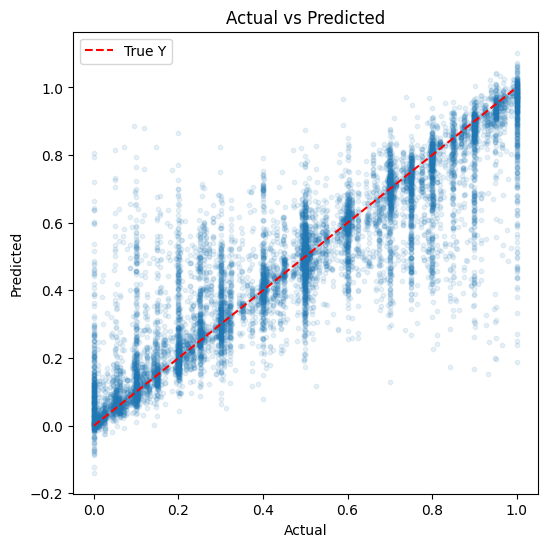

Test MSE: 0.0173
Test MAE: 0.0816
Test R^2 Score: 0.8132
Kendall's Tau: 0.7494, p-value: 0.0000e+00
Test results saved to ./xgboost/XGB_val_results.json


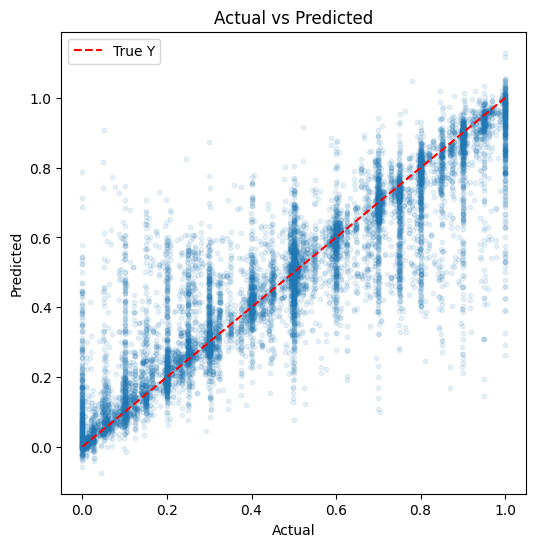

In [66]:
best_model.fit(hf.convert_to_numeric(X_train), y_train)
evaluate_model(best_model, X_test, y_test, save_file=True, save_path="./xgboost/XGB_test_results.json", show_plot=True)
evaluate_model(best_model, X_val, y_val, save_file=True, save_path="./xgboost/XGB_val_results.json", show_plot=True)